Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import r2_score
import json
import requests
import wandb

layers = tf.keras.layers
EarlyStopping = tf.keras.callbacks.EarlyStopping

DATA_FILE = "paranal_specific_dataset.csv"

PRESSURE_LEVELS = [700, 500, 300, 250, 200]

FEATURE_ORDER = [
    "airmass",
    "pressure",
    "temp_2m", "temp_30m", "temp_ground",
    "temp_gradient_ground_30m",
    "dew_point_depression_2m",
    "wind_speed_10m", "wind_speed_30m",
    "wind_shear_10_30",
    "wind_dir_sin", "wind_dir_cos",
    "wind_w_std",
    "rain_intensity",
    "ir_temperature", "pwv",

    "temp_2m_roll3h_mean",
    "temp_2m_trend_3h",
    "wind_speed_10m_roll3h_mean",
    "wind_speed_10m_trend_3h",
    "wind_speed_30m_roll3h_mean",
    "wind_speed_30m_trend_3h",

    "pressure_trend_3h",
    "wind_w_std_roll3h_mean",
]
TARGET = "seeing"

Data

In [ ]:
try:
    raw_dataset = pd.read_csv(DATA_FILE, encoding="utf-8")
    print(f"data is loaded: {len(raw_dataset)} rows")
except FileNotFoundError:
    raise SystemExit(
        f"{DATA_FILE} is not found"
    )

dataset = raw_dataset.copy()

data is loaded: 36709 rows


Wandb

In [ ]:
wandb.init(
    project="seeing-prediction",
    name="DNN-v2"
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mohamad-kr (mohamad-kr-github) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Add Feature

In [ ]:
wind_rad = np.deg2rad(dataset["wind_dir_10m"])
dataset["wind_dir_sin"] = np.sin(wind_rad)
dataset["wind_dir_cos"] = np.cos(wind_rad)

dataset = dataset.sort_values("datetime").reset_index(drop=True)

for col in ["temp_2m", "wind_speed_10m", "wind_speed_30m"]:
    dataset[f"{col}_roll3h_mean"] = dataset[col].rolling(3, min_periods=1).mean()
    dataset[f"{col}_trend_3h"] = dataset[col] - dataset[col].shift(3)

dataset["pressure_trend_3h"] = dataset["pressure"] - dataset["pressure"].shift(3)
dataset["wind_w_std_roll3h_mean"] = dataset["wind_w_std"].rolling(3, min_periods=1).mean()

Read Data

In [ ]:
print("empty cell:")
print(dataset.isna().sum())

valid_subset_cols = [col for col in (FEATURE_ORDER + [TARGET]) if col in dataset.columns]
dataset = dataset.dropna(subset=valid_subset_cols)
print(f"after clean data: {len(dataset)} rows")

dataset["log_seeing"] = np.log1p(dataset[TARGET])
LOG_TARGET = "log_seeing"

empty cell:
datetime                      0
airmass                       0
pressure                      0
temp_2m                       0
temp_30m                      0
temp_ground                   0
temp_gradient_ground_30m      0
dew_point_depression_2m       0
wind_speed_10m                0
wind_speed_30m                0
wind_shear_10_30              0
wind_dir_10m                  0
wind_w_std                    0
rain_intensity                0
ir_temperature                0
pwv                           0
seeing                        0
wind_dir_sin                  0
wind_dir_cos                  0
temp_2m_roll3h_mean           0
temp_2m_trend_3h              3
wind_speed_10m_roll3h_mean    0
wind_speed_10m_trend_3h       3
wind_speed_30m_roll3h_mean    0
wind_speed_30m_trend_3h       3
pressure_trend_3h             3
wind_w_std_roll3h_mean        0
dtype: int64
after clean data: 36706 rows


Clean Data

In [ ]:
print(dataset.isna().sum())
print(dataset.info())

datetime                      0
airmass                       0
pressure                      0
temp_2m                       0
temp_30m                      0
temp_ground                   0
temp_gradient_ground_30m      0
dew_point_depression_2m       0
wind_speed_10m                0
wind_speed_30m                0
wind_shear_10_30              0
wind_dir_10m                  0
wind_w_std                    0
rain_intensity                0
ir_temperature                0
pwv                           0
seeing                        0
wind_dir_sin                  0
wind_dir_cos                  0
temp_2m_roll3h_mean           0
temp_2m_trend_3h              0
wind_speed_10m_roll3h_mean    0
wind_speed_10m_trend_3h       0
wind_speed_30m_roll3h_mean    0
wind_speed_30m_trend_3h       0
pressure_trend_3h             0
wind_w_std_roll3h_mean        0
log_seeing                    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 36706 entries, 3 to 36708
Data columns (total 

Split the data into training and test sets

In [ ]:
dataset = dataset.sort_values("datetime").reset_index(drop=True)
dataset["week_block"] = pd.to_datetime(dataset["datetime"], utc=True).dt.to_period("W").astype(str)

blocks_in_order = dataset["week_block"].drop_duplicates().tolist()
n_blocks = len(blocks_in_order)

n_test_blocks = max(1, round(n_blocks * 0.15))
test_blocks = set(blocks_in_order[-n_test_blocks:])
remaining_blocks = blocks_in_order[:-n_test_blocks]

rng_blocks = np.random.default_rng(0)
remaining_blocks = list(remaining_blocks)
rng_blocks.shuffle(remaining_blocks)
n_cv_blocks = max(1, round(len(remaining_blocks) * (0.15 / 0.85)))
cv_blocks = set(remaining_blocks[:n_cv_blocks])
train_blocks = set(remaining_blocks[n_cv_blocks:])

train_dataset = dataset[dataset["week_block"].isin(train_blocks)]
cv_dataset = dataset[dataset["week_block"].isin(cv_blocks)]
test_dataset = dataset[dataset["week_block"].isin(test_blocks)]

bins = [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 100]
print(pd.cut(test_dataset[TARGET], bins=bins).value_counts().sort_index())

Inspect the data

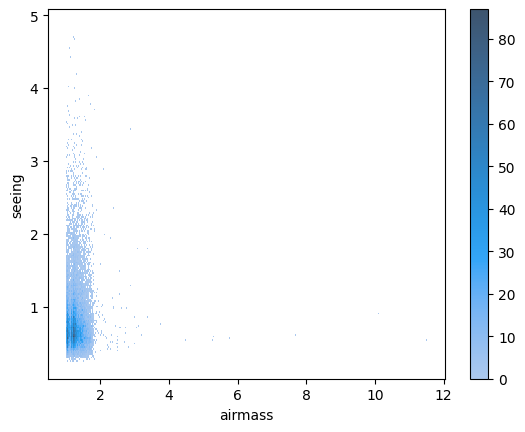

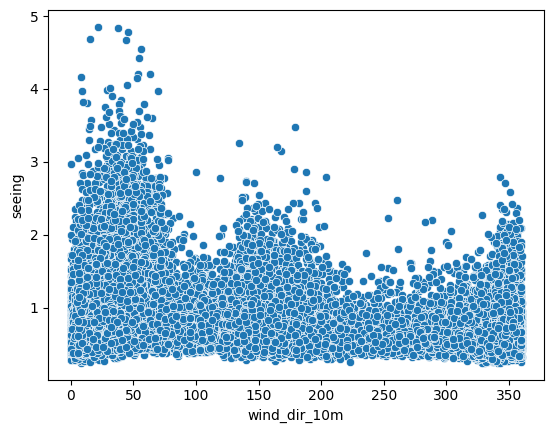

In [ ]:
sns.histplot(data=dataset, x="airmass", y="seeing", cbar=True)
plt.show()

sns.scatterplot(data=dataset, x="wind_dir_10m", y="seeing")
plt.show()

Split features from labels

In [ ]:
x_train = train_dataset[FEATURE_ORDER].select_dtypes(include=np.number).copy()
x_cv = cv_dataset[FEATURE_ORDER].select_dtypes(include=np.number).copy()
x_test = test_dataset[FEATURE_ORDER].select_dtypes(include=np.number).copy()

y_train = train_dataset[LOG_TARGET].copy()
y_cv = cv_dataset[LOG_TARGET].copy()
y_test_log = test_dataset[LOG_TARGET].copy()
y_test_real = test_dataset[TARGET].copy()

wandb.config.update({
    "model": "DNN",
    "n_features": len(FEATURE_ORDER),
    "train_samples": len(x_train),
    "test_samples": len(x_test)
})

Normalization

In [ ]:
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(x_train))

print(normalizer.mean)
print(normalizer.variance)

tf.Tensor(
[[ 1.28642726e+00  7.44012939e+02  1.25200357e+01  1.29119625e+01
   1.80137081e+01  5.10174656e+00  2.89866695e+01  5.61640644e+00
   6.46089554e+00  8.44489217e-01  2.10898861e-01  3.98515224e-01
   1.89614937e-01  1.56983161e+00 -8.59721985e+01  3.27149892e+00
   1.25205526e+01 -1.53777213e-03  5.61450768e+00  5.77820186e-03
   6.45940971e+00  5.56564471e-03  3.89086577e-04  1.89572468e-01]], shape=(1, 24), dtype=float32)
tf.Tensor(
[[4.7207665e-02 1.8034006e+00 7.5891423e+00 7.5533338e+00 6.2186217e+00
  3.2961214e+00 7.9661217e+01 1.1570503e+01 1.3948751e+01 1.4360787e+00
  2.8867820e-01 5.0802910e-01 8.2493955e-03 2.1978336e+01 1.5026414e+02
  7.5505242e+00 7.2481399e+00 2.0447934e+00 1.0319291e+01 7.5589752e+00
  1.2514518e+01 9.2013016e+00 9.5804036e-01 4.0970217e-03]], shape=(1, 24), dtype=float32)


DNN

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 24)             │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,758 (159.22 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 49 (200.00 B)

 Optimizer params: 27,140 (106.02 KB)

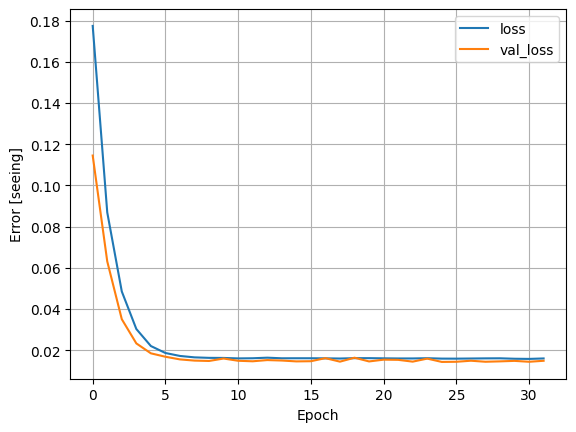

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('Error [seeing]')
  plt.legend()
  plt.grid(True)

# early_stopping
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=7,
                               restore_best_weights = True)
def build_and_compile_model(norm):
  reg = tf.keras.regularizers.l2(1e-3)
  model = keras.Sequential([
      norm,
      layers.Dense(128, activation='relu', kernel_regularizer=reg),
      layers.Dropout(0.3),
      layers.Dense(64, activation='relu', kernel_regularizer=reg),
      layers.Dropout(0.3),
      layers.Dense(32, activation='relu', kernel_regularizer=reg),
      layers.Dense(1)
  ])

  model.compile(loss='mse',
                metrics=['mae'],
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

dnn_model = build_and_compile_model(normalizer)

history = dnn_model.fit(
    x_train,
    y_train,
    batch_size=64,
    validation_data=(x_cv, y_cv),
    verbose=0, epochs=1000,
    callbacks= [early_stopping]
)

dnn_model.summary()
plot_loss(history)

Performance

In [ ]:
test_pred_log = dnn_model.predict(x_test, verbose=0).flatten()
test_predictions = np.expm1(test_pred_log)

mae_real = np.mean(np.abs(test_predictions - y_test_real))
mse_real = np.mean((test_predictions - y_test_real) ** 2)
r2 = r2_score(y_test_real, test_predictions)

Error = pd.DataFrame(
    {"loss(MSE)": [mse_real], "MAE": [mae_real], "R2": [r2]}, index=["Test Set"]
)
mae = mae_real
rmse = np.sqrt(mse_real)
print(Error)

          loss(MSE)       MAE        R2
Test Set   0.056079  0.166229  0.664502


Make predictions

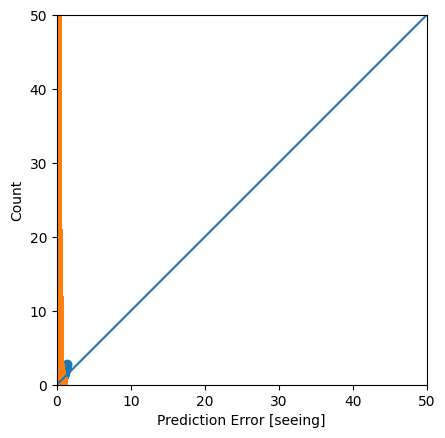

In [ ]:
a = plt.axes(aspect='equal')
plt.scatter(test_pred_log, test_predictions)
plt.xlabel('True Values [seeing]')
plt.ylabel('Predictions [seeing]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

# cost function
error = test_predictions - test_pred_log
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [seeing]')
_ = plt.ylabel('Count')

 Feature importance

In [ ]:
baseline_pred = np.expm1(dnn_model.predict(x_test, verbose=0).flatten())
baseline_mae = np.mean(np.abs(baseline_pred - y_test_real))

importances = {}
rng = np.random.default_rng(0)
for col in x_train.columns:
    shuffled = x_test.copy()
    shuffled[col] = rng.permutation(shuffled[col].values)
    shuffled_pred = np.expm1(dnn_model.predict(shuffled, verbose=0).flatten())
    shuffled_mae = np.mean(np.abs(shuffled_pred - y_test_real))
    importances[col] = shuffled_mae - baseline_mae

importance_series = pd.Series(importances).sort_values(ascending=False)
print(importance_series)

wind_dir_sin                  0.042526
temp_2m                       0.035723
wind_speed_10m                0.024555
wind_speed_10m_roll3h_mean    0.022442
wind_speed_30m                0.016644
temp_2m_roll3h_mean           0.012660
wind_dir_cos                  0.010161
temp_2m_trend_3h              0.007218
wind_w_std                    0.006429
wind_speed_30m_roll3h_mean    0.006217
temp_30m                      0.005524
temp_ground                   0.004127
wind_w_std_roll3h_mean        0.004100
wind_shear_10_30              0.004025
temp_gradient_ground_30m      0.002968
rain_intensity                0.001305
pressure                      0.001233
pwv                           0.001143
pressure_trend_3h             0.000674
wind_speed_30m_trend_3h       0.000617
ir_temperature                0.000541
wind_speed_10m_trend_3h       0.000445
dew_point_depression_2m       0.000366
airmass                       0.000050
dtype: float64


In [ ]:
wandb.log({
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2,

    "batch_size": 64,
    "epochs": 1000,

    "dense_1": 128,
    "dense_2": 64,
    "dense_3": 32,

    "dropout": 0.3,
    "l2": 1e-3
})

wandb.finish()

wandb.finish()

MAE,▁
R2,▁
RMSE,▁
batch_size,▁
dense_1,▁
dense_2,▁
dense_3,▁
dropout,▁
epochs,▁
l2,▁
MAE,0.16623


Save Model

In [ ]:
dnn_model.save('dnn_model.keras')
plt.show()